# Hao dataset (differently processed)

In [1]:
import scanpy as sc
import seaborn as sns
import pandas as pd
import numpy as numpy
import matplotlib.pyplot as plt
from tueplots import fonts, fontsizes

import matplotlib.pyplot as plt
import matplotlib as mpl
from itertools import chain
from matplotlib.patches import Rectangle, Patch
import os
import sys
from jax import random
from jax import flatten_util
import jax.numpy as np
from tueplots.constants.color import palettes
from tueplots import bundles
from sklearn.preprocessing import LabelEncoder

from matplotlib.animation import FuncAnimation, PillowWriter

cm = 1/2.54  # centimeters in inches

# Build an absolute path from this notebook's parent directory
module_path = os.path.abspath(os.path.join('..', 'src'))

# Add to sys.path if not already present
if module_path not in sys.path:
    sys.path.append(module_path)

# Load our modules
from utils import *
from tsne_jax import *

# For plotting

tex_path = '/ceph/ibmi/it/users/zabel/texlive/2025/bin/x86_64-linux' # <-- IMPORTANT: Change this to your actual path
os.environ['PATH'] = tex_path + os.pathsep + os.environ['PATH']

plt.rcParams.update({
    "text.usetex": True,
})

plt.rcParams.update(fonts.aistats2022_tex(family="serif"))
plt.rcParams.update(fontsizes.aistats2022())

## Load the dataset and annotation

In [2]:
# Dataset
adata = sc.read_h5ad('../data/single_cell_Hao/2025-05-31_Hao_full_annotated.h5ad')
adata

AnnData object with n_obs × n_vars = 149483 × 33538
    obs: 'cell_type', 'individual', 'condition'

In [3]:
sc.pp.recipe_zheng17(adata)

/ceph/ibmi/it/users/zabel/miniconda3/envs/tsnenew/lib/python3.13/site-packages/scanpy/preprocessing/_recipes.py:185: FutureWarning: Use sc.pp.highly_variable_genes instead
  filter_result = filter_genes_dispersion(
/ceph/ibmi/it/users/zabel/miniconda3/envs/tsnenew/lib/python3.13/functools.py:934: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


In [4]:
# Annotation
anno = pd.read_csv('../data/single_cell_Hao/GSE164378_sc.meta.data_3P.csv', index_col=0)
anno

,nCount_ADT,nFeature_ADT,nCount_RNA,nFeature_RNA,orig.ident,lane,donor,time,celltype.l1,celltype.l2,celltype.l3,Phase,Batch
L1_AAACCCAAGAAACTCA,7535,217,10823,2915,SeuratProject,L1,P2,7,Mono,CD14 Mono,CD14 Mono,G1,Batch1
L1_AAACCCAAGACATACA,6013,209,5864,1617,SeuratProject,L1,P1,7,CD4 T,CD4 TCM,CD4 TCM_1,G1,Batch1
L1_AAACCCACAACTGGTT,6620,213,5067,1381,SeuratProject,L1,P4,2,CD8 T,CD8 Naive,CD8 Naive,S,Batch1
L1_AAACCCACACGTACTA,3567,202,4786,1890,SeuratProject,L1,P3,7,NK,NK,NK_2,G1,Batch1
L1_AAACCCACAGCATACT,6402,215,6505,1621,SeuratProject,L1,P4,7,CD8 T,CD8 Naive,CD8 Naive,G1,Batch1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
E2L8_TTTGTTGGTCGTGATT,4170,197,9346,2201,SeuratProject,E2L8,P5,7,CD8 T,CD8 Naive,CD8 Naive,S,Batch2
E2L8_TTTGTTGGTGTGCCTG,6927,209,9318,2938,SeuratProject,E2L8,P5,2,Mono,CD14 Mono,CD14 Mono,G1,Batch2
E2L8_TTTGTTGGTTAGTTCG,4222,206,11619,3224,SeuratProject,E2L8,P8,0,B,B intermediate,B intermediate kappa,S,Batch2
E2L8_TTTGTTGGTTGGCTAT,6063,217,15436,3999,SeuratProject,E2L8,P5,2,Mono,CD16 Mono,CD16 Mono,G1,Batch2


## Subset annotation to cell ids in adata

In [5]:
anno_subset = anno.loc[adata.obs_names.to_list(),]
anno_subset

,nCount_ADT,nFeature_ADT,nCount_RNA,nFeature_RNA,orig.ident,lane,donor,time,celltype.l1,celltype.l2,celltype.l3,Phase,Batch
L1_AAACCCAAGAAACTCA,7535,217,10823,2915,SeuratProject,L1,P2,7,Mono,CD14 Mono,CD14 Mono,G1,Batch1
L1_AAACCCAAGACATACA,6013,209,5864,1617,SeuratProject,L1,P1,7,CD4 T,CD4 TCM,CD4 TCM_1,G1,Batch1
L1_AAACCCACAACTGGTT,6620,213,5067,1381,SeuratProject,L1,P4,2,CD8 T,CD8 Naive,CD8 Naive,S,Batch1
L1_AAACCCACACGTACTA,3567,202,4786,1890,SeuratProject,L1,P3,7,NK,NK,NK_2,G1,Batch1
L1_AAACCCACAGCATACT,6402,215,6505,1621,SeuratProject,L1,P4,7,CD8 T,CD8 Naive,CD8 Naive,G1,Batch1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
E2L8_TTTGTTGGTCGTGATT,4170,197,9346,2201,SeuratProject,E2L8,P5,7,CD8 T,CD8 Naive,CD8 Naive,S,Batch2
E2L8_TTTGTTGGTGTGCCTG,6927,209,9318,2938,SeuratProject,E2L8,P5,2,Mono,CD14 Mono,CD14 Mono,G1,Batch2
E2L8_TTTGTTGGTTAGTTCG,4222,206,11619,3224,SeuratProject,E2L8,P8,0,B,B intermediate,B intermediate kappa,S,Batch2
E2L8_TTTGTTGGTTGGCTAT,6063,217,15436,3999,SeuratProject,E2L8,P5,2,Mono,CD16 Mono,CD16 Mono,G1,Batch2


In [6]:
# Check same order of obs_names

adata.obs_names.to_list() == anno_subset.index.to_list()

True

## Prepare data for unsupervised learning / 2D projections

In [7]:
df = adata.to_df()
df

,HES4,ISG15,TNFRSF18,TNFRSF4,MMP23B,RPL22,RBP7,EFHD2,PADI4,CDA,...,S100B,MT-ND1,MT-ND2,MT-CO1,MT-CO2,MT-ATP6,MT-CO3,MT-ND3,MT-ND4,MT-CYB
L1_AAACCCAAGAAACTCA,-0.247503,-0.751735,-0.224923,-0.230073,-0.189782,-0.217850,1.398572,0.537717,-0.334310,0.727873,...,-0.19625,0.570220,0.326348,0.881763,0.548193,-0.317132,0.522445,0.257429,-0.329355,-0.080802
L1_AAACCCAAGACATACA,-0.247503,-0.751735,-0.224923,-0.230073,-0.189782,0.163579,-0.469032,-0.179201,-0.334310,-0.498341,...,-0.19625,-2.121810,-3.551910,-2.130270,-1.199343,-0.648008,-1.785417,-1.463015,-1.571860,0.224245
L1_AAACCCACAACTGGTT,-0.247503,-0.751735,-0.224923,-0.230073,-0.189782,1.309131,-0.469032,-1.072443,-0.334310,-0.498341,...,-0.19625,-0.605861,-1.013228,-0.734922,-0.055891,-0.464748,-1.203535,-0.476153,0.226753,-0.229036
L1_AAACCCACACGTACTA,-0.247503,-0.751735,-0.224923,-0.230073,-0.189782,-0.152207,-0.469032,1.149089,-0.334310,-0.498341,...,-0.19625,0.249032,-1.129040,0.367696,0.931865,0.314351,0.641775,-1.864037,0.732667,-0.572872
L1_AAACCCACAGCATACT,-0.247503,-0.751735,-0.224923,-0.230073,-0.189782,0.330318,-0.469032,-0.256677,-0.334310,-0.498341,...,-0.19625,-1.325549,-0.675295,-1.974731,-0.837172,-1.082877,-1.045444,-0.954907,-0.032594,-0.424438
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
E2L8_TTTGTTGGTCGTGATT,-0.247503,0.157653,-0.224923,-0.230073,-0.189782,1.312510,-0.469032,-1.072443,-0.334310,-0.498341,...,-0.19625,-0.351341,0.471730,0.414465,-0.827938,0.681253,0.748511,0.425618,0.544989,1.145292
E2L8_TTTGTTGGTGTGCCTG,2.081535,0.327750,-0.224923,-0.230073,-0.189782,-2.124717,1.686049,0.739894,-0.334310,3.001861,...,-0.19625,1.083606,1.073849,1.073525,0.382981,-0.510359,0.403313,0.449085,0.214512,0.019433
E2L8_TTTGTTGGTTAGTTCG,-0.247503,-0.751735,-0.224923,-0.230073,-0.189782,-0.814518,-0.469032,-1.072443,-0.334310,-0.498341,...,-0.19625,1.000197,0.695940,0.193694,0.941431,0.784769,0.896828,0.633340,1.233632,1.328615
E2L8_TTTGTTGGTTGGCTAT,1.382730,1.545577,-0.224923,-0.230073,-0.189782,-1.890109,-0.469032,0.839147,-0.334310,-0.498341,...,-0.19625,0.806057,1.323190,1.205537,0.202685,0.056279,0.246185,-0.242473,0.413878,-0.409600


In [8]:
celltypes_l1 = anno_subset['celltype.l1'].unique()
celltypes_l2 = sorted(anno_subset['celltype.l2'].unique())
donors = anno_subset['donor'].unique()
#print(donors, celltypes_l1, celltypes_l2)

### Compute mean and covariance

In [9]:
means = []
vars = []
participants = []
celltypes = []

for celltype in celltypes_l1:
  for donor in donors:
    subset = (anno_subset['donor']==donor) & (anno_subset['celltype.l1']==celltype)
    df_subset = df[subset]
    masked_df = np.where(df_subset.values==0, np.nan, df_subset.values)
    mean = numpy.nanmean(masked_df, axis=0)
    means.append(mean)
    var = numpy.nanvar(masked_df, axis=0)
    vars.append(var)
    participants.append(donor)
    celltypes.append(celltype)

In [10]:
# nan to zero

standardized_means = numpy.nan_to_num(np.array(means))
standardized_covs = numpy.nan_to_num(np.array(vars))


### Select top % most variant genes

In [11]:
# Set the top x% threshold (e.g., top 50%)
top_percent = 10

# Calculate variance for each column
variances = pd.DataFrame(standardized_means).var()

# Determine the cutoff variance value
cutoff = variances.quantile(1 - top_percent / 100)

# Filter columns with variance in the top x%
X = pd.DataFrame(standardized_means).loc[:, (variances >= cutoff)]
vars = pd.DataFrame(standardized_covs).loc[:, (variances >= cutoff)]

#covs = covs_new.loc[:, (pd.DataFrame(X_new).var() <= pd.DataFrame(X_new).var().quantile(1 - 0.01 / 100))]
#X = X_new.loc[:, (pd.DataFrame(X_new).var() <= pd.DataFrame(X_new).var().quantile(1 - 0.01 / 100))]

X = X.values
vars = vars.values

<Figure size 960x720 with 0 Axes>

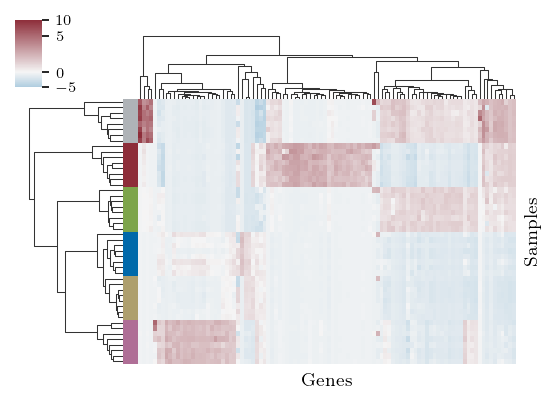

In [12]:
le = LabelEncoder()
color_encoder = le.fit_transform(celltypes)
customized_palette = palettes.tue_plot[[0, 2, 3, 4, 5, 7]]
cs = [customized_palette[i] for i in color_encoder]

cmap = mpl.colors.LinearSegmentedColormap.from_list("", [palettes.tue_plot[3], "whitesmoke", palettes.tue_plot[0]])
celltypes_unique = le.inverse_transform([0, 1, 2, 3, 4, 5])

fig = plt.figure()
g = sns.clustermap(X, row_colors=cs, cmap=cmap, 
                   xticklabels=False, yticklabels=False, 
                   norm=(MidpointNormalize(midpoint=0, vmin=np.min(X), 
                                           vmax=np.max(X))),
                   figsize=(0.5*18.0*cm, 0.7*0.5*18.0*cm))
g.ax_heatmap.tick_params(right=False, bottom=False)
g.ax_heatmap.set_xlabel('Genes')
g.ax_heatmap.set_ylabel('Samples')
handles = [Patch(facecolor=palettes.tue_plot[i]) for i in range(len(celltypes_unique))]
#g.savefig('../figures_and_animations/hao_mean_1.pdf')

<Figure size 960x720 with 0 Axes>

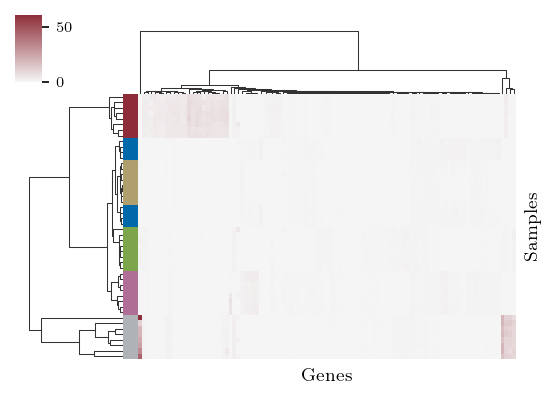

In [13]:
fig = plt.figure()
cmap2 = mpl.colors.LinearSegmentedColormap.from_list("", ["whitesmoke", palettes.tue_plot[0]])
g = sns.clustermap(vars, row_colors=cs, cmap=cmap2, 
                   xticklabels=False, yticklabels=False, 
                   #norm=(MidpointNormalize(vmin=np.min(vars), 
                   #                        vmax=np.max(vars))),
                   figsize=(0.5*18.0*cm, 0.7*0.5*18.0*cm))
g.ax_heatmap.tick_params(right=False, bottom=False)
g.ax_heatmap.set_xlabel('Genes')
g.ax_heatmap.set_ylabel('Samples')
handles = [Patch(facecolor=palettes.tue_plot[i]) for i in range(len(celltypes_unique))]
#g.savefig('../figures_and_animations/hao_mean_cov.pdf')

## Compute t-SNE embedding

In [14]:
# random initialisation
key = random.PRNGKey(12)
y_guess = random.normal(key, shape=(X.shape[0], 2))

# get optimal embedding
Y_star = tsne_fwd(X, y_guess)


===> Finding 47 nearest neighbors using Annoy approximate search using euclidean distance...
   --> Time elapsed: 0.07 seconds
===> Calculating affinity matrix...
   --> Time elapsed: 0.00 seconds
===> Running optimization with exaggeration=12.00, lr=4.00 for 250 iterations...
Iteration   50, KL divergence 0.4070, 50 iterations in 0.8355 sec
Iteration  100, KL divergence 0.4070, 50 iterations in 0.8339 sec
Iteration  150, KL divergence 0.4070, 50 iterations in 0.7263 sec
Iteration  200, KL divergence 0.4070, 50 iterations in 0.8519 sec
Iteration  250, KL divergence 0.4070, 50 iterations in 0.6723 sec
   --> Time elapsed: 3.94 seconds
===> Running optimization with exaggeration=1.00, lr=48.00 for 1000 iterations...
Iteration   50, KL divergence 0.0078, 50 iterations in 0.5046 sec
Iteration  100, KL divergence 0.0069, 50 iterations in 0.5308 sec
Iteration  150, KL divergence 0.0068, 50 iterations in 0.5287 sec
Iteration  200, KL divergence 0.0068, 50 iterations in 0.4508 sec
Iteration  2

In [15]:
Y_star.shape

(48, 2)

## Sensitivity Analysis

In [16]:
# reshape for sensitivity and uncertainty analysis
X_flat, X_unflattener = flatten_util.ravel_pytree(X)   # row-wise
Y_flat, Y_unflattener = flatten_util.ravel_pytree(Y_star)

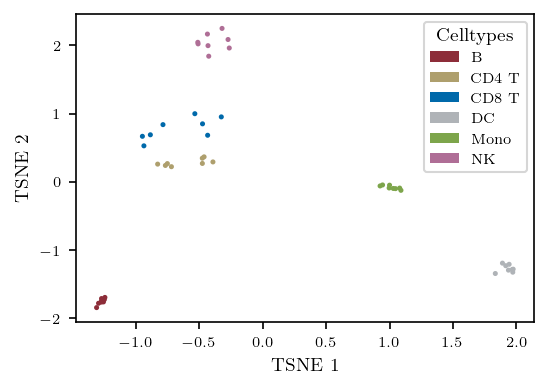

In [17]:
with plt.rc_context({**bundles.aistats2022(family="serif")}):
  fig = plt.figure(figsize=(0.5*18.0*cm, 0.7*0.5*18.0*cm))
  plt.scatter(*Y_star.T, c=cs, s=2)
  plt.xlabel('TSNE 1')
  plt.ylabel('TSNE 2')
  handles = [Patch(facecolor=customized_palette[i]) for i in range(len(celltypes_unique))]
  plt.legend(handles, celltypes_unique, title='Celltypes')
  #,bbox_to_anchor=(0.5, 0.5), bbox_transform=plt.gcf().transFigure, loc='center left', ncols=1)
  #plt.savefig('../figures_and_animations/hao_mean_2.pdf')

In [18]:
KL_divergence_dy(X_flat, Y_flat, X_unflattener, Y_unflattener, perplexity=30.0)

Array([-7.34726200e-08, -3.71801434e-09,  4.66407073e-08, -2.76195351e-08,
        2.87691364e-08, -1.81898940e-10,  1.04773790e-09, -1.49511834e-08,
       -1.49520929e-08, -1.54395821e-08,  1.08011591e-08, -1.80407369e-08,
        1.78697519e-08, -3.48300091e-08,  1.97669578e-08, -1.17070158e-08,
       -1.00044417e-07,  2.49769073e-07, -1.84809323e-07,  2.05705874e-07,
        4.00323188e-08,  2.10478902e-07,  9.67702363e-09,  1.94064341e-07,
       -1.12209818e-07,  1.59372576e-07, -8.38917913e-09,  1.18627213e-07,
        5.35437721e-08,  6.47851266e-08,  8.95743142e-08, -4.01050784e-07,
       -4.60335286e-07,  4.00992576e-07, -2.51282472e-07,  3.57220415e-07,
        6.52857125e-07, -4.64307959e-07,  3.76234311e-07, -3.70957423e-07,
        1.82793883e-07,  1.16415322e-10,  1.50765118e-07, -9.09785740e-08,
        5.57774911e-08, -2.27417331e-07, -3.84148734e-07, -2.36090273e-07,
        1.53231667e-08, -2.48837750e-08,  1.52140274e-08,  1.02241756e-07,
       -2.72557372e-08, -

In [19]:
sensitivities = compute_sensitivities(X_flat, Y_flat, X_unflattener, Y_unflattener, 30.0)

In [20]:
sensitivities.shape

(96, 4800)

<Figure size 960x720 with 0 Axes>

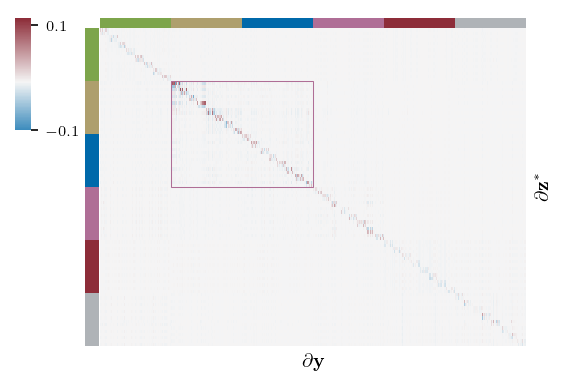

In [21]:
mpl.rcParams['text.latex.preamble'] = r'\usepackage{amsmath}'

# le = LabelEncoder()
# color_encoder = le.fit_transform(celltypes)
cs_row = list(chain.from_iterable((customized_palette[i], customized_palette[i]) for i in color_encoder))
cs_col = [customized_palette[i] for i in color_encoder for y in range(X.shape[1])]


# cmap = mpl.colors.LinearSegmentedColormap.from_list("", ["white", palettes.tue_plot[0]])
# celltypes_unique = ['Mono', 'CD4 T', 'CD8 T', 'NK', 'B', 'DC']
cmap2 = mpl.colors.LinearSegmentedColormap.from_list("", [palettes.tue_plot[3], "whitesmoke", palettes.tue_plot[0]])

fig = plt.figure()
g = sns.clustermap(sensitivities, cmap=cmap2, 
                   xticklabels=False, yticklabels=False,
                   row_cluster=False, col_cluster=False,
                   figsize=(0.5*18.0*cm, 0.7*0.5*18.0*cm), 
                   #dendrogram_ratio=0.12,
                   norm=(MidpointNormalize(midpoint=0, vmin=np.min(sensitivities), 
                                           vmax=np.max(sensitivities))),
                  row_colors=cs_row,
                  col_colors=cs_col,
                  cbar_pos=(0, 0.635, .03, .3),
                  cbar_kws={"ticks":[-0.1,0.1]},
                  dendrogram_ratio=(0.1, 0.01))
g.ax_heatmap.tick_params(right=False, bottom=False)
g.ax_heatmap.set_ylabel(r'$\partial \mathbf{z}^*$')
g.ax_heatmap.set_xlabel(r'$\partial \mathbf{y}$')

handles = [Patch(facecolor=palettes.tue_plot[i]) for i in range(len(celltypes_unique))]
#plt.legend(handles, celltypes_unique, title='Celltypes',
#          bbox_to_anchor=(0.98, 1), bbox_transform=plt.gcf().transFigure, loc='upper left', ncols=1)
g.ax_heatmap.add_patch(Rectangle((800, 16), 1600, 32, fill=False, edgecolor=palettes.tue_plot[7], lw=0.5, clip_on=False))
#g.savefig('../figures_and_animations/hao_mean_3.pdf')

## Uncertainty propagation

In [22]:
cov_final = np.multiply(sensitivities, vars.flatten()) @ sensitivities.T
cov_final = cov_final + 1e-5*np.eye(len(cov_final))

(96, 15)


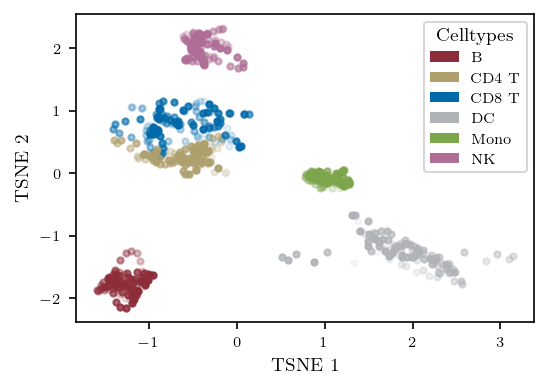

In [32]:
from utils import equipotential_standard_normal
import jax

n_samples = 15
y_int = [i for i in range(Y_star.shape[0])]
S = equipotential_standard_normal(2 * Y_star.shape[0], n_samples)
L, lower = jax.scipy.linalg.cho_factor(cov_final, lower=True)
samples = np.transpose(np.transpose(np.dot(L, S))+Y_flat)
print(samples.shape)

with plt.rc_context({**bundles.aistats2022(family="serif")}):
    fig = plt.figure(figsize=(0.5*18.0*cm, 0.7*0.5*18.0*cm))
    #plt.scatter(*Y_star.T, c=cs, s=2)
    for j, sample in enumerate(samples.T):
        sample = Y_unflattener(sample)
        for i, s in enumerate(sample): 
            plt.plot(s[0], s[1], c=cs[i], alpha=[i for i in numpy.arange(0.1, 1, 1/(n_samples+2))][j], marker='.')
    plt.xlabel('TSNE 1')
    plt.ylabel('TSNE 2')
    handles = [Patch(facecolor=customized_palette[i]) for i in range(len(celltypes_unique))]
    plt.legend(handles, celltypes_unique, title='Celltypes')
    #,bbox_to_anchor=(0.5, 0.5), bbox_transform=plt.gcf().transFigure, loc='center left', ncols=1)
    #plt.savefig('../figures_and_animations/hao_mean_4.pdf')

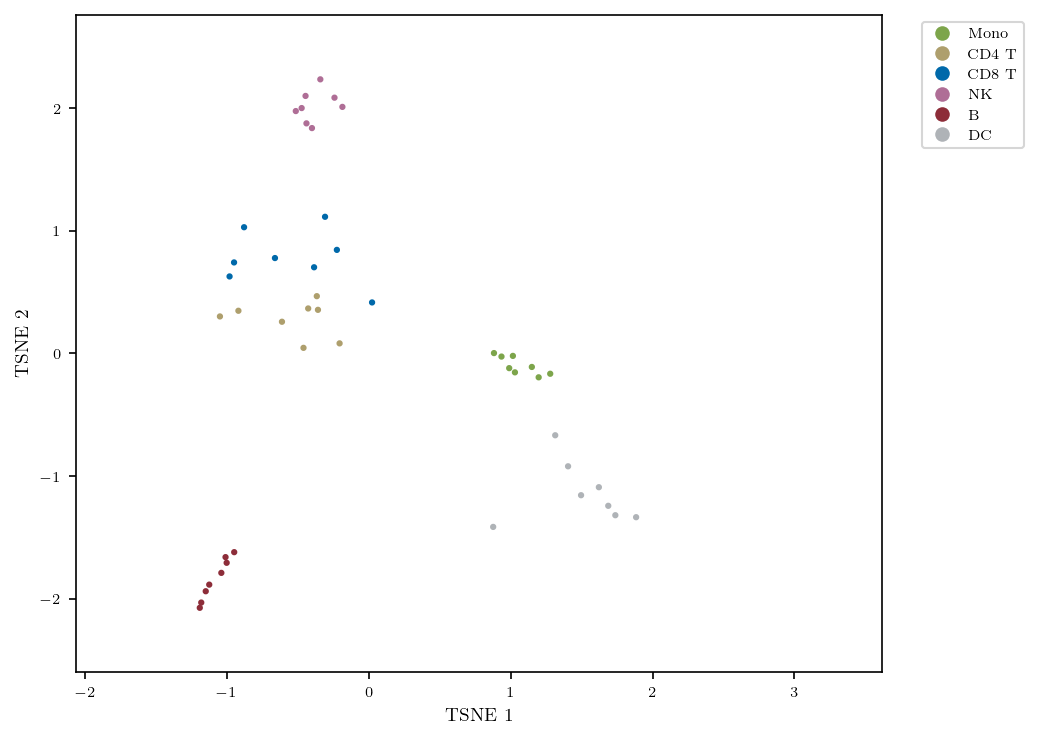

In [ ]:
def animate(samples, labels, output, cmap):
    """
    Creates and saves an animation of t-SNE embeddings over time.

    Args:
        samples (np.ndarray): A numpy array of shape (n_points * 2, n_frames)
                              containing the sequence of 2D embeddings.
        labels (np.ndarray): The labels for each point, used for coloring.
        output (str): The path to save the output animation file (e.g., "animation.gif").
        cmap (list): A list of colors, e.g. in RGB format.
    """
    plt.rcParams['axes.grid'] = False

    # Encode labels to integers for color mapping
    le = LabelEncoder()
    color_encoder = le.fit_transform(labels)
    labels_dict = dict(zip(labels, color_encoder))
    cs = [cmap[i] for i in color_encoder]
    labels_set = list(dict.fromkeys(labels))

    # Determine the axis limits by finding the min/max coordinates across ALL frames
    # This prevents the plot from resizing during the animation.
    fig, ax = plt.subplots(figsize=(7, 5))
    sample_0 = samples[:, 0]
    sample_0 = sample_0.reshape((len(labels), 2))
    minimum_x = np.min(np.array([i.reshape((len(labels), 2)) for i in samples.T])[:, :, 0])
    maximum_x = np.max(np.array([i.reshape((len(labels), 2)) for i in samples.T])[:, :, 0])
    minimum_y = np.min(np.array([i.reshape((len(labels), 2)) for i in samples.T])[:, :, 1])
    maximum_y = np.max(np.array([i.reshape((len(labels), 2)) for i in samples.T])[:, :, 1])
    
    # Set axis limits with a 10% margin
    ax.set_xlim((minimum_x - (0.1 * (maximum_x - minimum_x)), maximum_x + (0.1 * (maximum_x - minimum_x))))
    ax.set_ylim((minimum_y - (0.1 * (maximum_y - minimum_y)), maximum_y + (0.1 * (maximum_y - minimum_y))))
    ax.set_xlabel('TSNE 1')
    ax.set_ylabel('TSNE 2')

    # Initialize the scatter plot with the first frame of data
    scat = ax.scatter(sample_0[:, 0], sample_0[:, 1], c=cs, s=4)

    # Manually create a legend
    legend_patches = [plt.Line2D([0], [0], marker='o', color='w', 
                                 markerfacecolor=cmap[labels_dict[label]], 
                                 markersize=8, label=label)
                  for label in labels_set]
    ax.legend(handles=legend_patches, bbox_to_anchor=(1.04, 1), loc="upper left")    
    plt.tight_layout()

    def init():
        """Initializes the animation. Returns the artist to be updated."""
        return scat,

    def animate(i):
        """
        The update function for each frame of the animation.
        
        Args:
            i (int): The current frame index.
        """
        sample_i = samples[:, i]
        sample_i = sample_i.reshape((len(labels), 2))
        scat.set_offsets(sample_i)
        return scat, 
        
    anim = FuncAnimation(
        fig, animate, interval=1000, frames=samples.shape[1], blit=True, init_func=init)
    
    # Save the animation as a GIF file
    # PillowWriter is used for creating GIFs. FFMpegWriter can be used for movie formats like .mp4 or .mov.
    anim.save(output, dpi=150, writer=PillowWriter(fps=5))

animate(samples, celltypes, '../figures_and_animations/hao_mean_animation.gif', cmap=customized_palette)

In [34]:
n_samples = 15
print(samples.shape)
with plt.rc_context(bundles.beamer_moml()):
  for j, sample in enumerate(samples.T):
    plt.rcParams.update({'figure.figsize': (0.5*18.0*cm, 0.7*0.5*18.0*cm)})
    fig, ax = plt.subplots()
    #ax.set_xticklabels([])
    #ax.set_xticks([])
    #ax.set_yticklabels([])
    #ax.set_yticks([])
    ax.set_xlabel("TSNE 1")
    ax.set_ylabel("TSNE 2")
    #ax.set_facecolor((palettes.tue_plot[2], 0.3))
    minimum_x = np.min(np.array([i.reshape((int(samples.shape[0]/2), 2)) for i in samples.T])[:, :, 0])
    maximum_x = np.max(np.array([i.reshape((int(samples.shape[0]/2), 2)) for i in samples.T])[:, :, 0])
    minimum_y = np.min(np.array([i.reshape((int(samples.shape[0]/2), 2)) for i in samples.T])[:, :, 1])
    maximum_y = np.max(np.array([i.reshape((int(samples.shape[0]/2), 2)) for i in samples.T])[:, :, 1])
    
    # Set axis limits with a 10% margin
    ax.set_xlim((minimum_x - (0.05 * (maximum_x - minimum_x)), maximum_x + (0.05 * (maximum_x - minimum_x))))
    ax.set_ylim((minimum_y - (0.1 * (maximum_y - minimum_y)), maximum_y + (0.1 * (maximum_y - minimum_y))))
    sample = sample.reshape((48, 2))
    for i, s in enumerate(sample): 
        plt.plot(s[0], s[1], c=cs[i], marker='.')
    #plt.tight_layout()
    handles = [Patch(facecolor=customized_palette[i]) for i in range(len(celltypes_unique))]
    plt.legend(handles, celltypes_unique, title='Celltypes')
    fig.patch.set_alpha(0.0)
    plt.savefig(f'../figures_and_animations/tsne_{j}.pdf')
    plt.close(fig)

(96, 15)
